In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score
import joblib
import joblib
import os
# import warnings
# warnings.filterwarnings('ignore')

In [4]:
file_path = r'C:\Users\Anna\Desktop\MAGA2\implementationML\session\credit-card-ml-deployment\data\UCI_Credit_Card.csv'
df = pd.read_csv(file_path)
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")

Размер данных: 30000 строк, 25 столбцов


In [5]:
df.head() 

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [7]:
df.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [8]:
# Пропуски в данных
print(f"Всего пропусков: {df.isnull().sum().sum()}")

Всего пропусков: 0


In [9]:
# Анализ целевой переменной
target = df['default.payment.next.month']
print(f"Дефолт: {target.mean()*100:.1f}%")

Дефолт: 22.1%


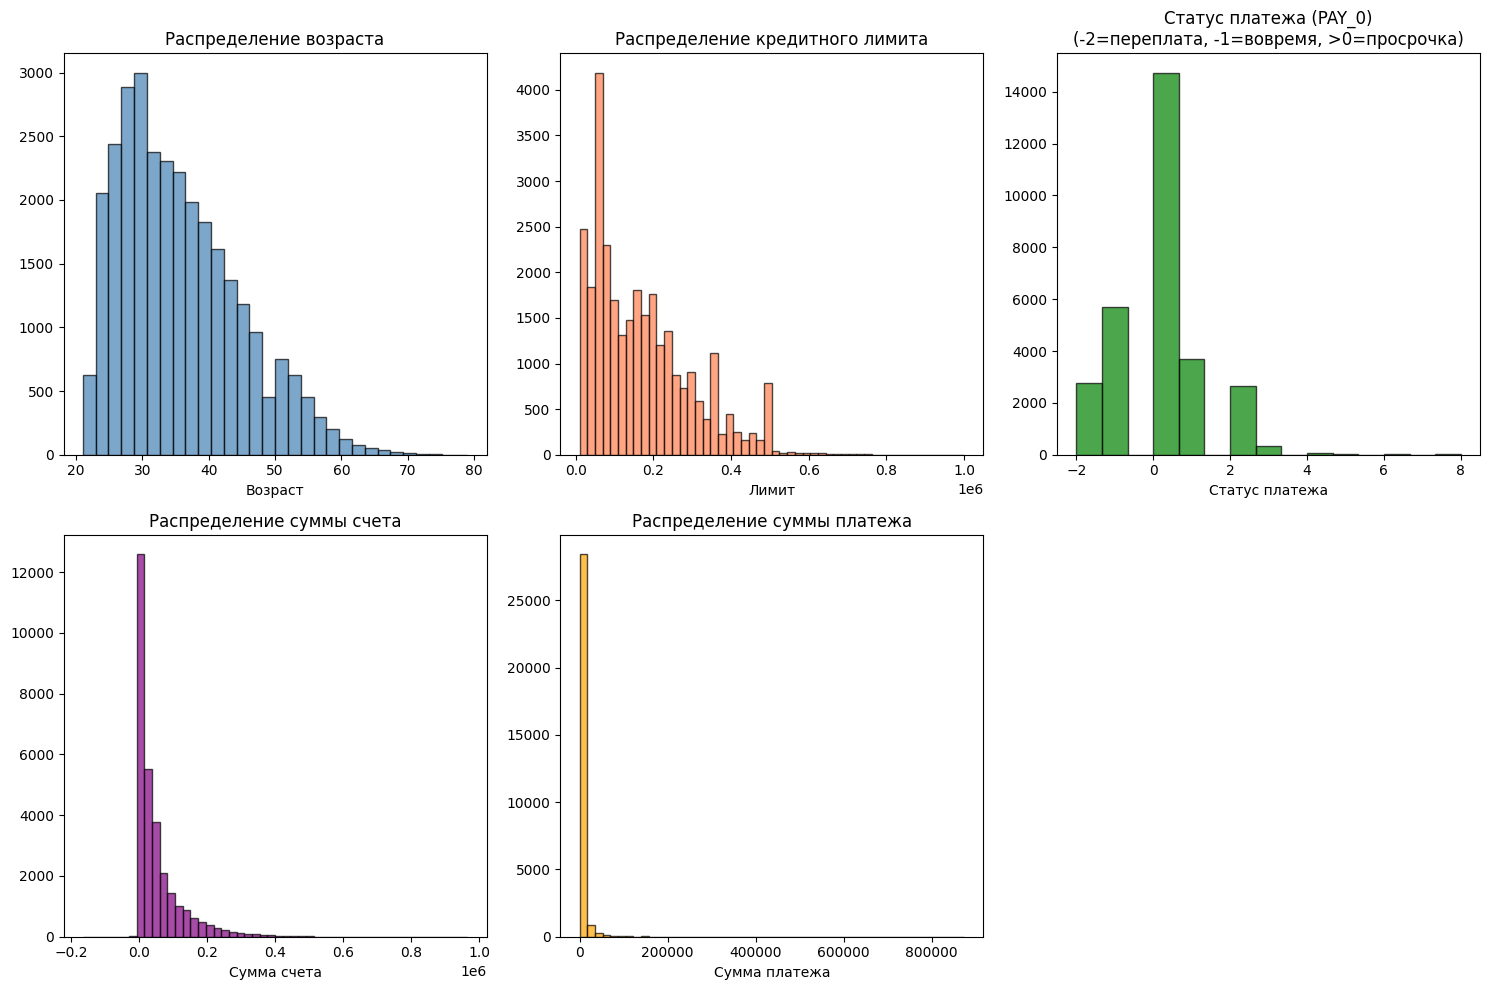

In [10]:
#Визуализация распределений
# Фигура с графиками распределения
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# 1. Возраст
axes[0].hist(df['AGE'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Распределение возраста')
axes[0].set_xlabel('Возраст')

# 2. Кредитный лимит
axes[1].hist(df['LIMIT_BAL'], bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_title('Распределение кредитного лимита')
axes[1].set_xlabel('Лимит')

# 3. Статус платежа (PAY_0)
axes[2].hist(df['PAY_0'], bins=15, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('Статус платежа (PAY_0)\n(-2=переплата, -1=вовремя, >0=просрочка)')
axes[2].set_xlabel('Статус платежа')

# 4. Сумма счета (BILL_AMT1)
axes[3].hist(df['BILL_AMT1'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[3].set_title('Распределение суммы счета')
axes[3].set_xlabel('Сумма счета')

# 5. Сумма платежа (PAY_AMT1)
axes[4].hist(df['PAY_AMT1'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[4].set_title('Распределение суммы платежа')
axes[4].set_xlabel('Сумма платежа')

# Скрываем шестой график (если не нужен)
axes[5].set_visible(False)

plt.tight_layout()
plt.show()

In [11]:
# 1. Возраст
print(f"Средний возраст: {df['AGE'].mean():.1f}")
print(f"Медианный возраст: {df['AGE'].median():.1f}")
print(f"25-й перцентиль: {df['AGE'].quantile(0.25):.1f}")
print(f"75-й перцентиль: {df['AGE'].quantile(0.75):.1f}")

# Вывод: "Средний возраст клиентов — 35 лет, 50% клиентов в возрасте от 28 до 41 года"
# 2. Кредитный лимит
print(f"Медианный лимит: {df['LIMIT_BAL'].median():,.0f}")
print(f"90-й перцентиль: {df['LIMIT_BAL'].quantile(0.9):,.0f}")

# Вывод: "У 50% клиентов лимит до 140 000, у 90% — до 390 000"
#  3. Доля просрочек
delay_pct = (df['PAY_0'] > 0).mean() * 100
print(f"Просрочка в PAY_0: {delay_pct:.1f}%")

# Вывод: "Только X% клиентов имеют просрочку в текущем месяце"
# 4. Анализ суммы счета (BILL_AMT1)
print(f"Среднее: {df['BILL_AMT1'].mean():,.0f}")
print(f"Медиана: {df['BILL_AMT1'].median():,.0f}")
print(f"Стандартное отклонение: {df['BILL_AMT1'].std():,.0f}")
print(f"Минимум: {df['BILL_AMT1'].min():,.0f}")
print(f"Максимум: {df['BILL_AMT1'].max():,.0f}")

print(f"\n25-й перцентиль: {df['BILL_AMT1'].quantile(0.25):,.0f}")
print(f"50-й перцентиль: {df['BILL_AMT1'].quantile(0.50):,.0f}")
print(f"75-й перцентиль: {df['BILL_AMT1'].quantile(0.75):,.0f}")
print(f"90-й перцентиль: {df['BILL_AMT1'].quantile(0.9):,.0f}")

negative_pct = (df['BILL_AMT1'] < 0).mean() * 100
print(f"\nДоля отрицательных значений: {negative_pct:.1f}%")
zero_pct = (df['BILL_AMT1'] == 0).mean() * 100
print(f"Доля нулевых значений: {zero_pct:.1f}%")

# 5. Анализ суммы платежа (PAY_AMT1)
print(f"Среднее: {df['PAY_AMT1'].mean():,.0f}")
print(f"Медиана: {df['PAY_AMT1'].median():,.0f}")
print(f"Стандартное отклонение: {df['PAY_AMT1'].std():,.0f}")
print(f"Минимум: {df['PAY_AMT1'].min():,.0f}")
print(f"Максимум: {df['PAY_AMT1'].max():,.0f}")

print(f"\n25-й перцентиль: {df['PAY_AMT1'].quantile(0.25):,.0f}")
print(f"50-й перцентиль: {df['PAY_AMT1'].quantile(0.50):,.0f}")
print(f"75-й перцентиль: {df['PAY_AMT1'].quantile(0.75):,.0f}")
print(f"90-й перцентиль: {df['PAY_AMT1'].quantile(0.9):,.0f}")

zero_pct_pay = (df['PAY_AMT1'] == 0).mean() * 100
print(f"\nДоля нулевых платежей: {zero_pct_pay:.1f}%")

Средний возраст: 35.5
Медианный возраст: 34.0
25-й перцентиль: 28.0
75-й перцентиль: 41.0
Медианный лимит: 140,000
90-й перцентиль: 360,000
Просрочка в PAY_0: 22.7%
Среднее: 51,223
Медиана: 22,382
Стандартное отклонение: 73,636
Минимум: -165,580
Максимум: 964,511

25-й перцентиль: 3,559
50-й перцентиль: 22,382
75-й перцентиль: 67,091
90-й перцентиль: 142,134

Доля отрицательных значений: 2.0%
Доля нулевых значений: 6.7%
Среднее: 5,664
Медиана: 2,100
Стандартное отклонение: 16,563
Минимум: 0
Максимум: 873,552

25-й перцентиль: 1,000
50-й перцентиль: 2,100
75-й перцентиль: 5,006
90-й перцентиль: 10,300

Доля нулевых платежей: 17.5%


In [12]:
# Корреляция PAY_0 с дефолтом
correlation_pay0 = df['PAY_0'].corr(df['default.payment.next.month'])
print(f"Корреляция PAY_0 с дефолтом: {correlation_pay0:.4f}")
correlations = df.corr()['default.payment.next.month'].sort_values(ascending=False)
print(correlations)

Корреляция PAY_0 с дефолтом: 0.3248
default.payment.next.month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
ID                           -0.013952
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                   

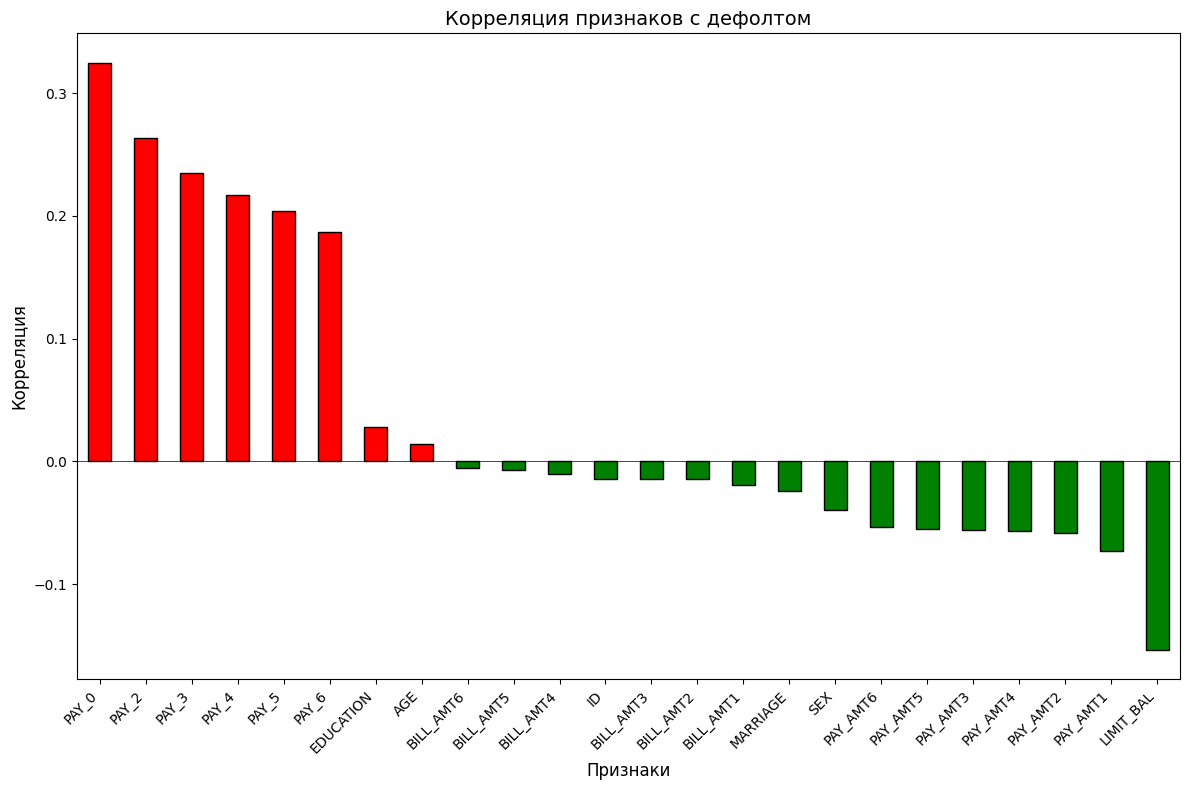

In [13]:
# Визуализация корреляции
plt.figure(figsize=(12, 8))
correlations = df.corr()['default.payment.next.month'].drop('default.payment.next.month').sort_values(ascending=False)

colors = ['red' if x > 0 else 'green' for x in correlations.values]
correlations.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Корреляция признаков с дефолтом', fontsize=14)
plt.xlabel('Признаки', fontsize=12)
plt.ylabel('Корреляция', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()


Вывод: результат анализа данных:
1. датасет содержит 30 000 записей без пропусков, с целевой переменной, имеющей дисбаланс классов (22.1% дефолтов, 77.9% не дефолтов). 
2. средний возраст клиентов составляет 35.5 лет (50% в диапазоне 28-41 год), медианный кредитный лимит — 140 000 рублей с разбросом от 10 000 до 1 000 000 рублей. 
3.ключевой предиктор дефолта - статус платежа PAY_0 (корреляция 0.3248), при этом 22.7% клиентов имеют просрочку, что практически совпадает с долей дефолтов. 
4. также значимые даннын - PAY_2 (0.2636) и PAY_3 (0.2353), 17.5% клиентов не вносят платежи вовсе, а 2.0% имеют отрицательный счёт (возвраты товаров). 
5. перед обучением модели требуется масштабирование признаков, балансировка классов и использование метрики F1-score вместо accuracy.

In [14]:

# Feature Engineering
# 1. Количество просрочек за 6 месяцев (самый важный!)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['DELAY_COUNT'] = (df[pay_cols] > 0).sum(axis=1)

# 2. Отношение платежа к лимиту
df['PAYMENT_RATIO'] = df['PAY_AMT1'] / (df['LIMIT_BAL'] + 1)

# 3. Отношение долга к лимиту
df['BILL_TO_LIMIT'] = df['BILL_AMT1'] / (df['LIMIT_BAL'] + 1)

# 4. Количество нулевых платежей
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
df['ZERO_PAYMENT_COUNT'] = (df[pay_amt_cols] == 0).sum(axis=1)

print(f"\n Добавлено 4 новых признака")



 Добавлено 4 новых признака


Вывод: 4 новых признака:
 DELAY_COUNT — сколько месяцев была просрочка у клиента
 PAYMENT_RATIO — платёж / лимит -какую часть лимита клиент платит
 BILL_TO_LIMIT — долг / лимит -какую часть лимита должен
 ZERO_PAYMENT_COUNT — сколько месяцев не платил клиет

In [15]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   30000 non-null

In [16]:
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,DELAY_COUNT,PAYMENT_RATIO,BILL_TO_LIMIT,ZERO_PAYMENT_COUNT
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,689.0,0.0,0.0,0.0,0.0,1,2,0.000000,0.195640,5
1,2,120000.0,2,2,2,26,-1,2,0,0,...,1000.0,1000.0,1000.0,0.0,2000.0,1,2,0.000000,0.022350,2
2,3,90000.0,2,2,2,34,0,0,0,0,...,1500.0,1000.0,1000.0,1000.0,5000.0,0,0,0.016866,0.324874,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,2019.0,1200.0,1100.0,1069.0,1000.0,0,0,0.039999,0.939781,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,36681.0,10000.0,9000.0,689.0,679.0,0,0,0.039999,0.172337,0


In [17]:
# Обучение новой модели
# Выбираем признаки
features = [
    'PAY_0', 'PAY_2', 'PAY_3',
    'DELAY_COUNT',
    'PAYMENT_RATIO',
    'BILL_TO_LIMIT',
    'ZERO_PAYMENT_COUNT',
    'AGE', 'LIMIT_BAL'
]

X = df[features]
y = df['default.payment.next.month']

print(f"Признаков: {len(features)}")
print(f"Размер данных: {X.shape}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# Масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение с балансировкой
model = RandomForestClassifier(
    random_state=42, 
    n_estimators=200, 
    max_depth=10,
    class_weight='balanced'
)
model.fit(X_train_scaled, y_train)

# Оценка
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(f"\nРезультаты:")
print(f"  F1-score: {f1_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

Признаков: 9
Размер данных: (30000, 9)

Результаты:
  F1-score: 0.5310
  Precision: 0.5044
  Recall: 0.5607
  ROC-AUC: 0.7722


Вывод: В результате обучения улучшенной модели Random Forest на 9 отобранных признаках (PAY_0, PAY_2, PAY_3, DELAY_COUNT, PAYMENT_RATIO, BILL_TO_LIMIT, ZERO_PAYMENT_COUNT, AGE, LIMIT_BAL) с добавлением балансировки классов (class_weight='balanced') и масштабированием признаков, модель показала F1-score = 0.5310, Precision = 0.5044, Recall = 0.5607, ROC-AUC = 0.7722. По сравнению с базовой моделью v1 (обученной на всех 23 признаках) удалось улучшить F1-score на 13% (с 0.47 до 0.53), а Recall — на 55% (с 0.36 до 0.56). Это означает, что модель v2 находит значительно больше реальных дефолтов, что критически важно для банка с точки зрения минимизации финансовых потерь. Модель v2 сохранена как model_v2.pkl и ее можно использовать в веб-сервисе.

In [ ]:
# Сохранить модель и scaler
joblib.dump(model, '../models/model_v2.pkl')
joblib.dump(scaler, '../models/scaler_v2.pkl')


model_v2.pkl сохранён в папке models/
scaler_v2.pkl сохранён в папке models/
